In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from google.colab import files
uploaded = files.upload()

Saving Telco_customer_churn.xlsx to Telco_customer_churn.xlsx


In [4]:
df = pd.read_excel("Telco_customer_churn.xlsx")

df['Total Charges'] = pd.to_numeric(
    df['Total Charges'],
    errors='coerce'
)

df['Total Charges'] = df['Total Charges'].fillna(0)

In [5]:
drop_cols = [
    'CustomerID',
    'Country',
    'State',
    'City',
    'Zip Code',
    'Lat Long',
    'Latitude',
    'Longitude',
    'Count',
    'Churn Reason',
    'Churn Score',
    'CLTV'
]

df = df.drop(columns=drop_cols)

In [7]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(
        df[col].astype(str)
    )

In [8]:
X = df.drop(
    columns=[
        'Churn Value',
        'Churn Label'
    ]
)

y = df['Churn Value']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [10]:
print(X_train.shape)
print(X_test.shape)

(5634, 19)
(1409, 19)


In [11]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, n_estimators=300, random_state=42)

In [12]:
y_pred = rf.predict(X_test)

y_prob = rf.predict_proba(X_test)[:,1]

In [13]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy :", round(accuracy,4))
print("Precision:", round(precision,4))
print("Recall   :", round(recall,4))
print("F1 Score :", round(f1,4))
print("ROC AUC  :", round(roc_auc,4))

Accuracy : 0.807
Precision: 0.6711
Recall   : 0.5348
F1 Score : 0.5952
ROC AUC  : 0.8503


In [14]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.53      0.60       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



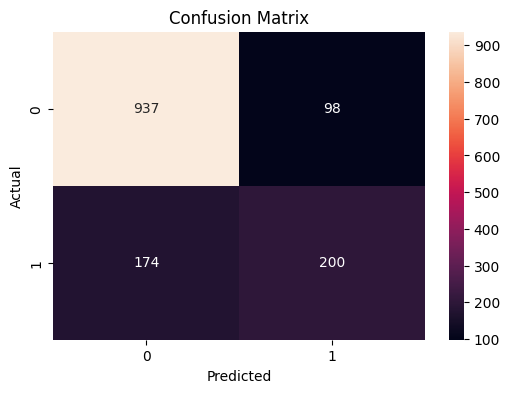

In [15]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [16]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
4,Tenure Months,0.155871
18,Total Charges,0.137980
17,Monthly Charges,0.136632
14,Contract,0.133474
8,Online Security,0.071790
3,Dependents,0.057295
11,Tech Support,0.056828
7,Internet Service,0.042450
16,Payment Method,0.040536
9,Online Backup,0.028085


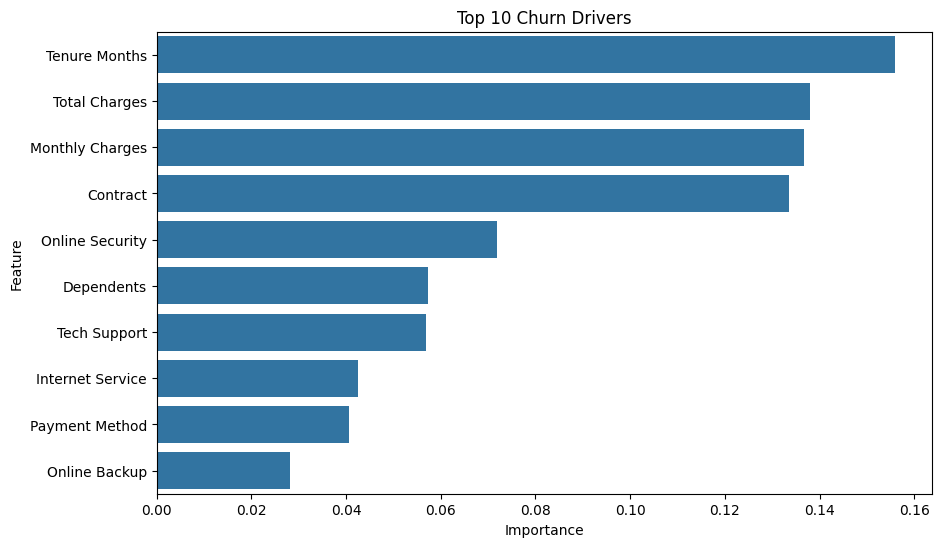

In [17]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Churn Drivers")

plt.show()

In [18]:
feature_importance.to_csv(
    "feature_importance.csv",
    index=False
)

predictions = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

predictions.to_csv(
    "churn_predictions.csv",
    index=False
)